# EDA on Retail Sales Data

## Oasis Infobyte – Data Analytics Internship

### Objective

The objective of this project is to perform a thorough Exploratory Data
Analysis (EDA) on retail sales data to uncover sales patterns, customer
behaviour trends, product performance, and actionable business insights.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Analysis Performed

This project covers:

1. Dataset inspection and data quality checks
2. Descriptive statistics
3. Monthly sales trend analysis
4. Quarterly sales trend analysis
5. Customer segment analysis
6. Region-wise order analysis
7. Top 10 best-selling products
8. Revenue analysis by product category
9. Correlation analysis
10. Discount versus profit analysis
11. Actionable business recommendations

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load the retail sales dataset

df = pd.read_csv("samplesuperstore.csv")

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [6]:
# Basic information about the dataset

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape of Dataset: (10194, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country/Region     object
City               object
State/Province     object
Postal Code        object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode

In [7]:
# Mean of numerical variables
# Descriptive Statistics

# Select numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Calculate Mean
mean_values = df[numeric_columns].mean()

# Calculate Median
median_values = df[numeric_columns].median()

# Calculate Mode
mode_values = df[numeric_columns].mode().iloc[0]

# Calculate Standard Deviation
std_values = df[numeric_columns].std()

# Create a summary table
descriptive_stats = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values,
    "Standard Deviation": std_values
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Row ID,5097.500000,5097.50,1.00,2942.898656
Sales,228.225854,53.91,12.96,619.906839
Quantity,3.791838,3.00,2.00,2.228317
Discount,0.155385,0.20,0.00,0.206249
Profit,28.673417,8.69,0.00,232.465115


In [8]:
# Convert Order Date to datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create Month column
df["Month"] = df["Order Date"].dt.to_period("M")

# Calculate monthly sales
monthly_sales = df.groupby("Month")["Sales"].sum()

# Display monthly sales
monthly_sales

Month
2023-01     14518.0550
2023-02      4519.8920
2023-03     56933.9090
2023-04     28295.3450
2023-05     26319.7670
2023-06     34669.4796
2023-07     33946.3930
2023-08     28918.3385
2023-09     82670.4288
2023-10     32413.3390
2023-11     78826.9567
2023-12     72008.3085
2024-01     18461.9156
2024-02     11951.4110
2024-03     39978.6280
2024-04     34195.2085
2024-05     30246.9465
2024-06     24797.2920
2024-07     28765.3250
2024-08     37057.0042
2024-09     64627.0460
2024-10     31407.1335
2024-11     75972.5635
2024-12     75532.5572
2025-01     18830.3310
2025-02     22978.8150
2025-03     53031.0690
2025-04     38829.1590
2025-05     57042.8380
2025-06     40937.1480
2025-07     40300.4990
2025-08     31716.8143
2025-09     73521.6629
2025-10     59831.0010
2025-11     79411.9658
2025-12     97502.2770
2026-01     44259.2140
2026-02     20301.1334
2026-03     60728.4808
2026-04     36779.0361
2026-05     45155.4822
2026-06     53056.0777
2026-07     45989.4960
2026-

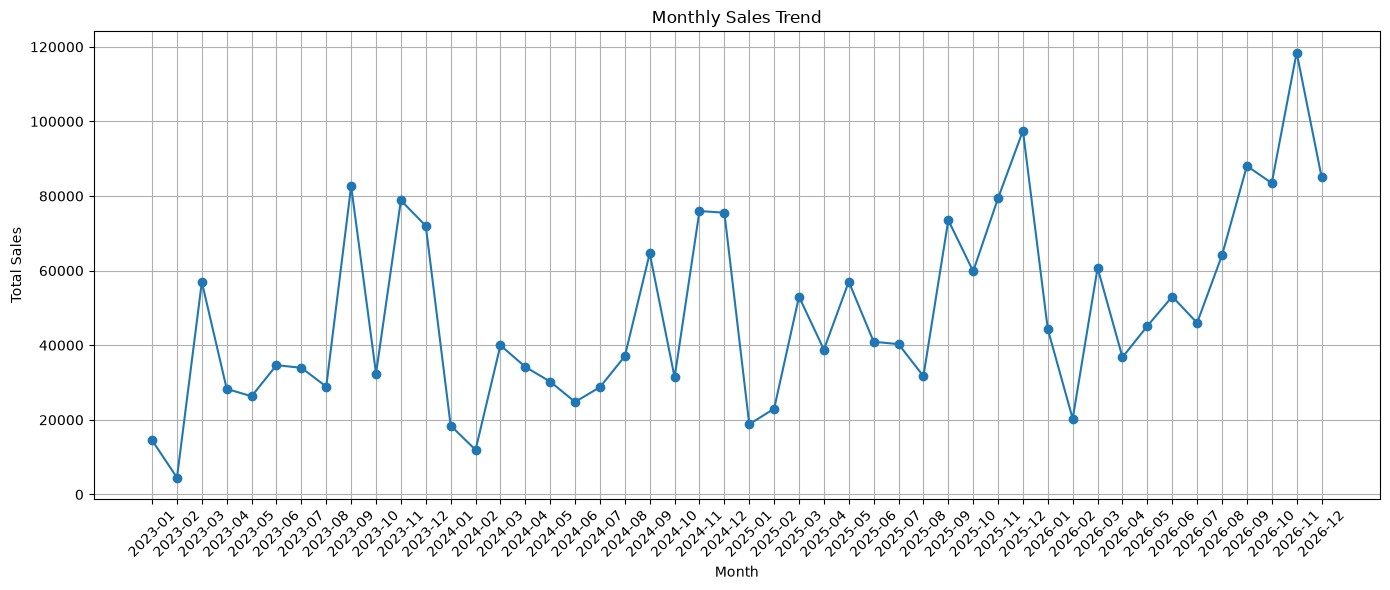

In [9]:
# Monthly Sales Trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation – Monthly Sales Trend

The monthly sales trend shows significant fluctuations in sales performance 
throughout the analyzed period.

- Sales vary considerably from month to month, indicating an inconsistent 
  monthly sales pattern.
- The highest monthly sales are observed around October 2026, reaching 
  approximately 118K.
- Some months, such as February 2023 and February 2024, show comparatively 
  low sales.
- The later period shows generally higher sales values compared with the 
  earlier period, indicating an overall improvement in sales performance.

These variations can help the business identify high-performing periods 
and plan inventory, promotions, and marketing campaigns accordingly.



In [10]:
# Calculate quarterly sales

df["Quarter"] = df["Order Date"].dt.to_period("Q")

quarterly_sales = df.groupby("Quarter")["Sales"].sum()

# Display quarterly sales
quarterly_sales

Quarter
2023Q1     75971.8560
2023Q2     89284.5916
2023Q3    145535.1603
2023Q4    183248.6042
2024Q1     70391.9546
2024Q2     89239.4470
2024Q3    130449.3752
2024Q4    182912.2542
2025Q1     94840.2150
2025Q2    136809.1450
2025Q3    145538.9762
2025Q4    236745.2438
2026Q1    125288.8282
2026Q2    134990.5960
2026Q3    198183.7860
2026Q4    287104.3210
Freq: Q-DEC, Name: Sales, dtype: float64

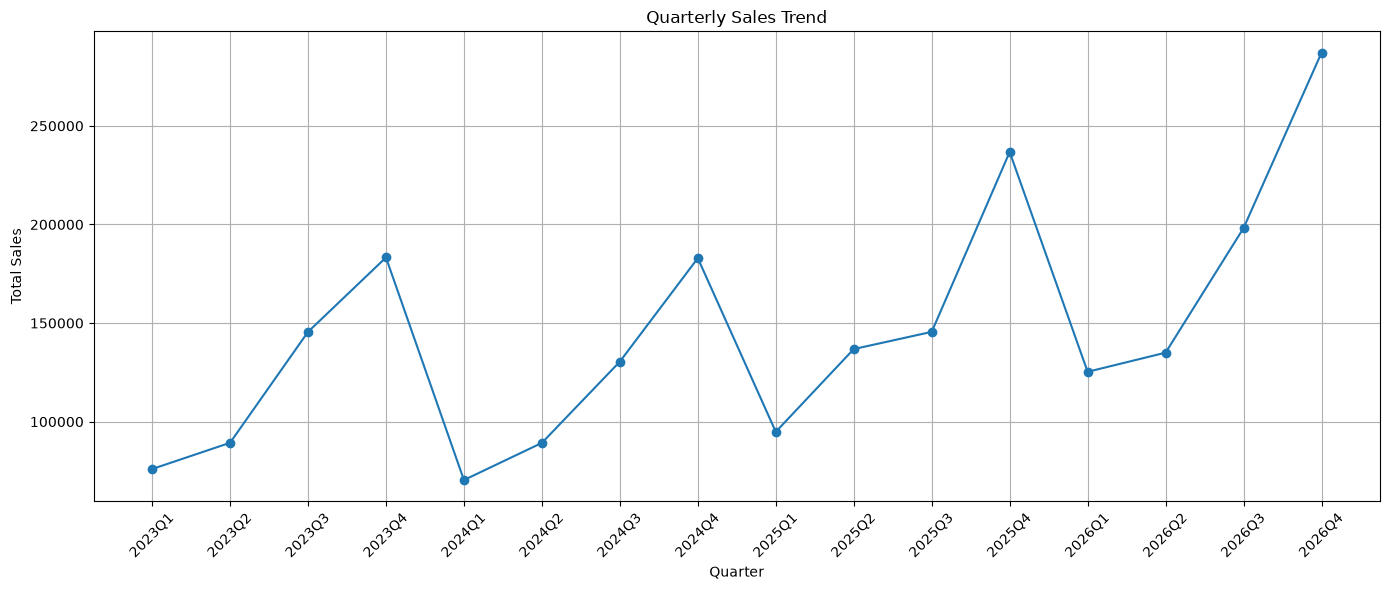

In [11]:
# Quarterly Sales Trend

plt.figure(figsize=(14, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation – Quarterly Sales Trend

The quarterly sales trend shows noticeable fluctuations across the analyzed period.

- Sales increased consistently from Q1 to Q4 during 2023, reaching approximately 183K in Q4.
- A significant decline was observed in Q1 2024, followed by recovery toward Q4 2024.
- Q4 2025 recorded a strong increase in sales of approximately 237K.
- Q4 2026 achieved the highest quarterly sales, at approximately 287K.
- Despite periodic declines, the overall quarterly trend indicates an upward movement in sales over time.

These trends can help the business identify strong quarters and plan inventory,
marketing campaigns, and sales targets more effectively.

In [12]:
# Check whether demographic columns are available

demographic_columns = ["Age", "Gender"]

available_demographics = [
    col for col in demographic_columns if col in df.columns
]

print("Available demographic columns:", available_demographics)

if not available_demographics:
    print("Age and Gender data are not available in this dataset.")

Available demographic columns: []
Age and Gender data are not available in this dataset.


### Customer Demographics – Data Availability

The dataset does not contain Age or Gender columns. Therefore, age-group
distribution and gender breakdown cannot be calculated reliably from the
available data.

No demographic values have been artificially created, as doing so could
introduce inaccurate information into the analysis.

Instead, customer analysis will focus on the demographic and customer-related
fields that are actually available in the dataset, such as Customer Segment
and Region.

In [13]:
# Customer Segment Distribution

segment_counts = df["Segment"].value_counts()

print("Customer Segment Distribution:")
print(segment_counts)

Customer Segment Distribution:
Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64


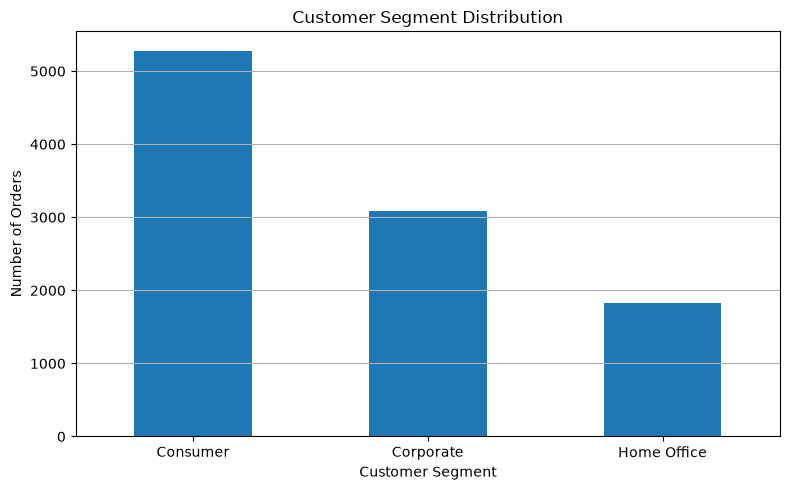

In [14]:
# Visualize Customer Segment Distribution

plt.figure(figsize=(8, 5))

segment_counts.plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Observation – Customer Segment Distribution

The Consumer segment accounts for the highest number of orders, with
approximately 5,300 orders.

The Corporate segment is the second-largest segment, with approximately
3,000 orders, while the Home Office segment has the lowest number of orders,
with approximately 1,800 orders.

This indicates that Consumer customers represent the largest portion of
orders in the dataset. Therefore, the business can prioritize consumer-focused
marketing strategies while also exploring opportunities to increase sales
from the Corporate and Home Office segments.

In [15]:
# Region-wise Order Distribution

region_counts = df["Region"].value_counts()

print("Region-wise Order Distribution:")
print(region_counts)

Region-wise Order Distribution:
Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64


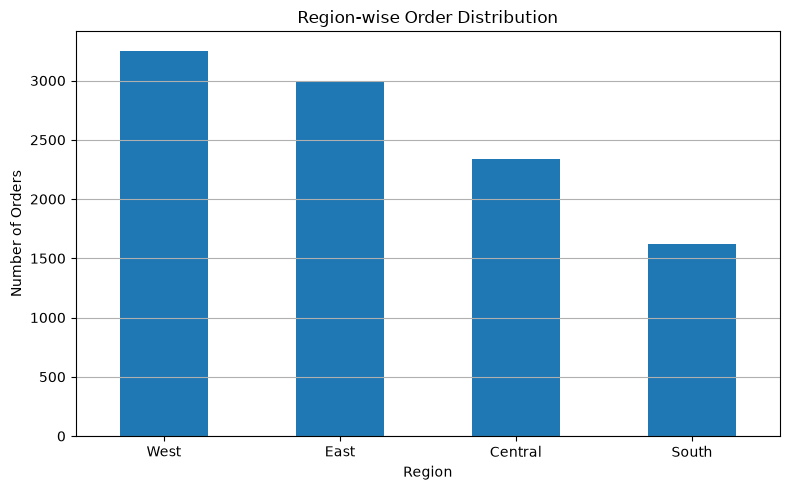

In [16]:
# Visualize Region-wise Order Distribution

plt.figure(figsize=(8, 5))

region_counts.plot(kind="bar")

plt.title("Region-wise Order Distribution")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Observation – Region-wise Order Distribution

The West region has the highest number of orders, with approximately 3,250
orders, followed by the East region with approximately 3,000 orders.

The Central region records approximately 2,350 orders, while the South region
has the lowest order volume at approximately 1,600 orders.

The distribution indicates that the business has stronger order activity in
the West and East regions. The relatively lower order volume in the South
region may represent an opportunity for targeted marketing and regional
growth strategies.

In [18]:
# Top 10 Best-Selling Products by Sales

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Best-Selling Products:")
print(top_products)

Top 10 Best-Selling Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


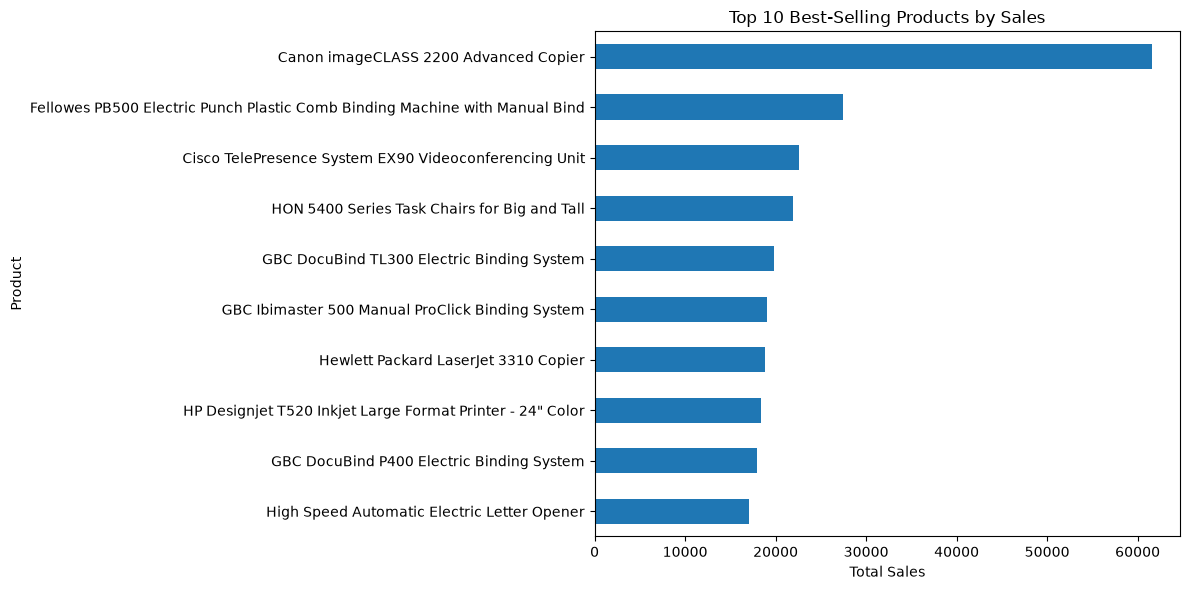

In [19]:
# Visualize Top 10 Best-Selling Products

plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Observation – Top 10 Best-Selling Products

The analysis identifies the top 10 products based on total sales revenue.

- Canon imageCLASS 2200 Advanced Copier is the highest-selling product,
  generating more than 60K in sales.
- Fellows PB500 Electric Punch Plastic Comb Binding Machine is the
  second-highest-selling product, with sales of approximately 27K.
- Cisco TelePresence System EX90 Videoconferencing Unit and HON 5400 Series
  Task Chairs for Big and Tall also generate sales above 20K.
- The remaining products in the top 10 contribute approximately 17K–20K
  in sales.

The business should monitor the availability of these high-performing
products and consider prioritizing them in inventory planning and marketing
strategies.

In [20]:
# Revenue by Product Category

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by Product Category:")
print(category_sales)

Revenue by Product Category:
Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64


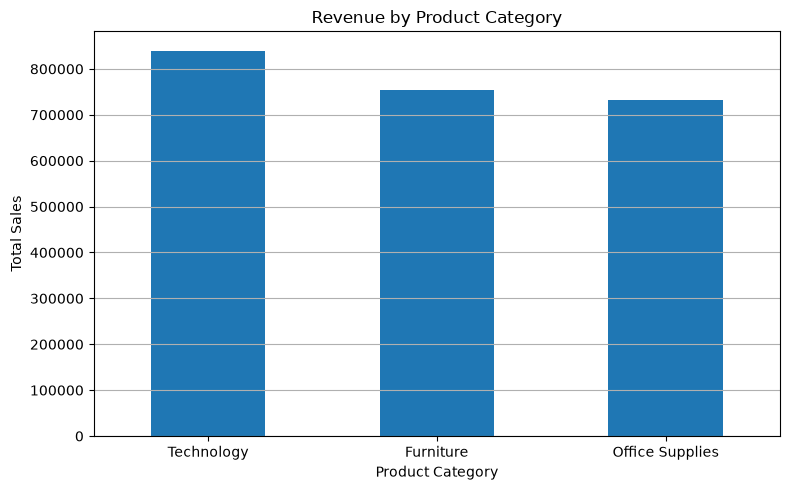

In [21]:
# Visualize Revenue by Product Category

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Observation – Revenue by Product Category

Technology is the highest-revenue product category, generating approximately
835K in total sales.

Furniture generates approximately 742K in sales, while Office Supplies
generates approximately 720K.

The results show that Technology contributes the largest share of revenue
among the three categories. The business should continue to focus on
high-performing Technology products while also identifying opportunities
to improve revenue from Furniture and Office Supplies.

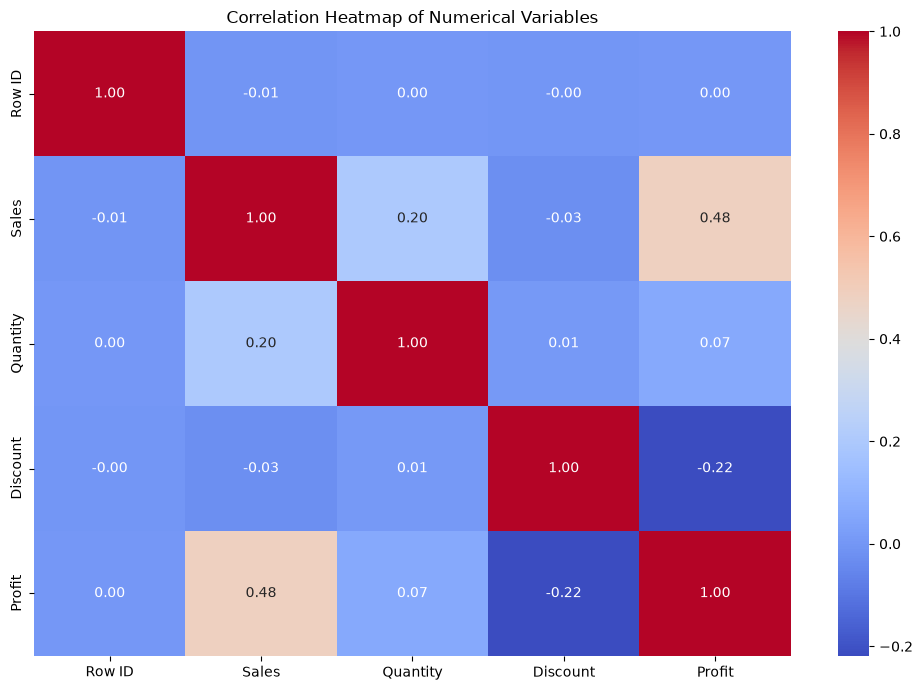

In [22]:
# Correlation Heatmap

numeric_data = df.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

### Observation – Correlation Heatmap

The correlation heatmap shows the relationships among the numerical variables
in the dataset.

- Sales and Profit have a moderate positive correlation of approximately 0.48,
  indicating that higher sales are generally associated with higher profit.
- Sales and Quantity show a weak positive correlation of approximately 0.20.
- Discount and Profit have a weak negative correlation of approximately -0.22,
  suggesting that higher discount levels may be associated with lower profit.
- Quantity and Profit have a very weak positive correlation of approximately 0.07.
- Row ID has almost no correlation with the other variables because it is only
  an identifier and does not represent a business metric.

Overall, Sales has the strongest positive relationship with Profit among the
main business variables, while Discount shows a negative relationship with
Profit.

In [23]:
# Create discount groups

df["Discount Group"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.40, 1.00],
    labels=[
        "0%",
        "1-10%",
        "11-20%",
        "21-30%",
        "31-40%",
        "Above 40%"
    ]
)

# Calculate average profit for each discount group
discount_profit = df.groupby(
    "Discount Group",
    observed=False
)["Profit"].mean()

discount_profit

Discount Group
0%            66.338799
1-10%         94.791354
11-20%        24.613875
21-30%       -45.710633
31-40%      -108.878256
Above 40%   -105.183731
Name: Profit, dtype: float64

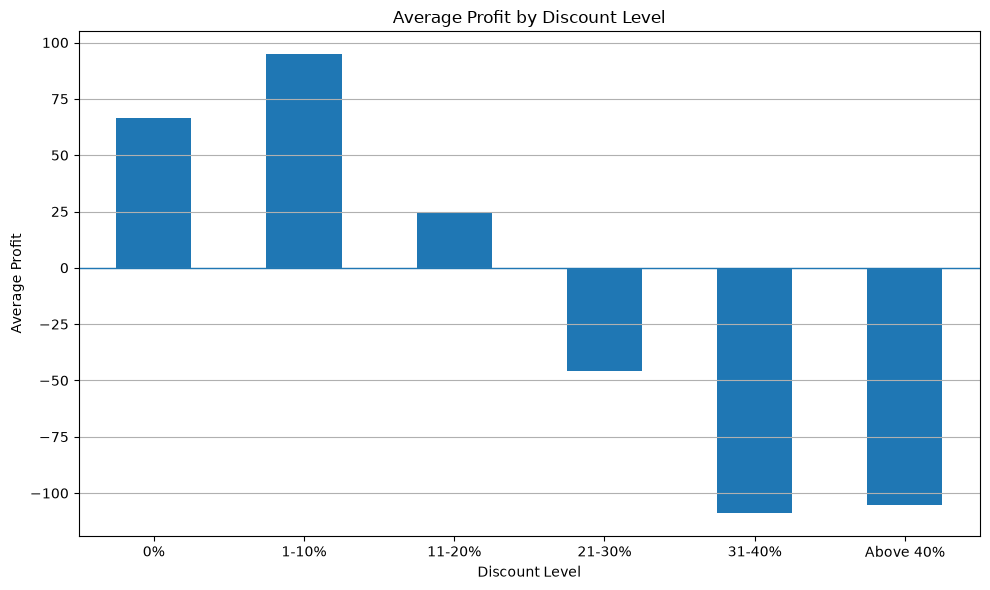

In [24]:
# Average Profit by Discount Group

plt.figure(figsize=(10, 6))

discount_profit.plot(kind="bar")

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount Level")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Observation – Discount vs Average Profit

The analysis reveals a clear relationship between discount levels and average
profit.

- Transactions with 0% discount generate a positive average profit of
  approximately 67.
- The 1–10% discount range has the highest average profit, at approximately 95.
- Average profit decreases to approximately 25 in the 11–20% discount range.
- Discounts of 21–30% result in a negative average profit of approximately -46.
- Higher discounts of 31–40% and above 40% result in substantially negative
  average profits, around -110 and -106 respectively.

This indicates that excessive discounting can significantly reduce
profitability. The business should carefully control high discount levels
and focus on discount strategies that maintain a healthy profit margin.

## Actionable Business Recommendations

Based on the exploratory data analysis, the following business
recommendations can be made:

1. **Prioritize high-performing products**
   
   Products such as the Canon imageCLASS 2200 Advanced Copier generate
   significantly higher sales than other products. The business should
   maintain adequate inventory for high-performing products and prioritize
   them in promotional campaigns.

2. **Control excessive discounting**
   
   The analysis shows that higher discount levels are associated with
   substantially lower average profit. Discounts above 20% should therefore
   be used selectively and monitored to avoid reducing profitability.

3. **Focus on the Technology category**
   
   Technology generates the highest revenue among the three product
   categories. The business should continue investing in high-performing
   Technology products while identifying opportunities to improve the
   performance of Furniture and Office Supplies.

4. **Develop regional growth strategies**
   
   The West and East regions have the highest order volumes, while the South
   region has comparatively fewer orders. The business can use targeted
   marketing campaigns and regional promotions to increase sales in
   underperforming regions.

5. **Prepare for high-performing sales periods**
   
   Quarterly and monthly analysis shows considerable fluctuations in sales,
   with particularly strong performance during later high-performing
   periods. Inventory and marketing resources should be planned in advance
   for periods with historically higher demand.

## Conclusion

The exploratory data analysis provided several useful insights into the
retail sales dataset.

Sales show considerable month-to-month and quarter-to-quarter variation,
while the overall long-term quarterly trend indicates growth. Consumer is
the largest customer segment by order volume, and the West region records
the highest number of orders.

At the product level, Canon imageCLASS 2200 Advanced Copier is the
highest-selling product by sales revenue. Among product categories,
Technology generates the highest total revenue.

The correlation analysis shows a moderate positive relationship between
Sales and Profit, while Discount has a negative relationship with Profit.
The discount-level analysis further indicates that excessive discounts can
lead to negative average profit.

Overall, the analysis demonstrates how exploratory data analysis can help
businesses understand sales trends, identify high-performing products and
regions, manage discounts, and make data-driven business decisions.